In [17]:
import pandas as pd
import shap

In [18]:
import pandas as pd
data = pd.read_csv('/Users/muhammadzuamaalamin/Documents/PengamanJaringan/dataset/Dataset_for_paper.csv',encoding='latin-1')
data

,file_name,Class,ACCESS_BACKGROUND_LOCATION,ACCESS_COARSE_LOCATION,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MEDIA_LOCATION,ACCESS_NETWORK_STATE,ACCESS_NOTIFICATION_POLICY,ACCESS_WIFI_STATE,...,BIND_DIRECTORY_SEARCH,BROADCAST_CLOSE_SYSTEM_DIALOGS,CAPTURE_SECURE_VIDEO_OUTPUT,WRITE_CLIPS,FLAG_GRANT_READ_URI_PERMISSION,FORCE_STOP_PACKAGES,GET_CLIPS,GET_INTENT_SENDER_INTENT,GET_TOP_AVTIVITY_INFO,INTERNAL_SYSTEM_WINDOW
0,0000000mapk00001_AndroidManifest.xml,0,0,1,1,1,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
1,0000000mapk00003_AndroidManifest.xml,0,0,1,1,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
2,0000000mapk00004_AndroidManifest.xml,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0000000mapk00005_AndroidManifest.xml,0,0,1,1,1,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
4,0000000mapk00006_AndroidManifest.xml,0,0,1,1,1,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126438,xcxin.filexpert_AndroidManifest.xml,1,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
126439,xyz.studiox.pixels_AndroidManifest.xml,1,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
126440,you.in.spark.energy_AndroidManifest.xml,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
126441,za.co.prosense.impression_AndroidManifest.xml,1,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [19]:
data.isnull().sum()

file_name                     0
Class                         0
ACCESS_BACKGROUND_LOCATION    0
ACCESS_COARSE_LOCATION        0
ACCESS_FINE_LOCATION          0
                             ..
FORCE_STOP_PACKAGES           0
GET_CLIPS                     0
GET_INTENT_SENDER_INTENT      0
GET_TOP_AVTIVITY_INFO         0
INTERNAL_SYSTEM_WINDOW        0
Length: 191, dtype: int64

In [20]:
data['Class'].value_counts()

Class
1    72392
0    54051
Name: count, dtype: int64

In [21]:
data = data.drop(columns=['file_name'])
data

,Class,ACCESS_BACKGROUND_LOCATION,ACCESS_COARSE_LOCATION,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MEDIA_LOCATION,ACCESS_NETWORK_STATE,ACCESS_NOTIFICATION_POLICY,ACCESS_WIFI_STATE,ACCOUNT_MANAGER,...,BIND_DIRECTORY_SEARCH,BROADCAST_CLOSE_SYSTEM_DIALOGS,CAPTURE_SECURE_VIDEO_OUTPUT,WRITE_CLIPS,FLAG_GRANT_READ_URI_PERMISSION,FORCE_STOP_PACKAGES,GET_CLIPS,GET_INTENT_SENDER_INTENT,GET_TOP_AVTIVITY_INFO,INTERNAL_SYSTEM_WINDOW
0,0,0,1,1,1,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,1,1,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,1,1,1,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,1,1,1,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126438,1,0,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
126439,1,0,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
126440,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
126441,1,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
data['Class'].value_counts()

Class
1    72392
0    54051
Name: count, dtype: int64

In [23]:
from sklearn.model_selection import train_test_split

X = data.drop('Class', axis=1)
y = data['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (101154, 189)
Shape of X_test: (25289, 189)
Shape of y_train: (101154,)
Shape of y_test: (25289,)


In [24]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score,f1_score, classification_report

In [25]:
class_labels = list(y_train.unique())
class_labels

[np.int64(1), np.int64(0)]

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import time


# ── Helper ──────────────────────────────────────────────────────────────────
def print_metrics(name, y_true, y_pred, training_time=None, testing_time=None):
    print(f"\n{'='*50}")
    print(f"  {name} Results")
    print(f"{'='*50}")
    if training_time is not None:
        print(f"  Training Time : {training_time:.4f}s")
    if testing_time is not None:
        print(f"  Testing Time  : {testing_time:.4f}s")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"  Precision Macro : {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"  Recall    : {recall_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"  Recall Macro   : {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"  F1-Score  : {f1_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"  F1-Score Macro : {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"\n  Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=[str(x) for x in class_labels], zero_division=0))

# 1. Random Forest Classifier
print("\n--- Training Random Forest Classifier ---")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)
start = time.time()
rf_model.fit(X_train, y_train)
rf_time = time.time() - start

start = time.time()
y_pred_rf = rf_model.predict(X_test)
rf_test_time = time.time() - start

print_metrics("Random Forest", y_test, y_pred_rf, training_time=rf_time, testing_time=rf_test_time)

# 2. XGBoost Classifier
print("\n--- Training XGBoost Classifier ---")
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.2,
    random_state=42
)
start = time.time()
xgb_model.fit(X_train, y_train)
xgb_time = time.time() - start

start = time.time()
y_pred_xgb = xgb_model.predict(X_test)
xgb_test_time = time.time() - start

print_metrics("XGBoost", y_test, y_pred_xgb, training_time=xgb_time, testing_time=xgb_test_time)

# 3. LightGBM Classifier
print("\n--- Training LightGBM Classifier ---")
lgbm_model = LGBMClassifier(
    n_estimators=200,
    max_depth=None,
    learning_rate=0.2,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)
start = time.time()
lgbm_model.fit(X_train, y_train)
lgbm_time = time.time() - start

start = time.time()
y_pred_lgbm = lgbm_model.predict(X_test)
lgbm_test_time = time.time() - start

print_metrics("LightGBM", y_test, y_pred_lgbm, training_time=lgbm_time, testing_time=lgbm_test_time)


--- Training Random Forest Classifier ---

  Random Forest Results
  Training Time : 19.9231s
  Testing Time  : 0.7934s
  Accuracy  : 0.9651
  Precision : 0.9651
  Precision Macro : 0.9644
  Recall    : 0.9651
  Recall Macro   : 0.9643
  F1-Score  : 0.9651
  F1-Score Macro : 0.9643

  Classification Report:

              precision    recall  f1-score   support

           1       0.96      0.96      0.96     10810
           0       0.97      0.97      0.97     14479

    accuracy                           0.97     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.97      0.97      0.97     25289


--- Training XGBoost Classifier ---

  XGBoost Results
  Training Time : 1.5128s
  Testing Time  : 0.0237s
  Accuracy  : 0.9626
  Precision : 0.9626
  Precision Macro : 0.9626
  Recall    : 0.9626
  Recall Macro   : 0.9610
  F1-Score  : 0.9626
  F1-Score Macro : 0.9618

  Classification Report:

              precision    recall  f1-score   support

         

In [27]:
# ── Rekap Perbandingan Semua Model ─────────────────────────────────────────
import pandas as pd

def collect_metrics(name, y_true, y_pred, train_time=None, test_time=None):
    return {
        "Model"              : name,
        "F1 Macro"           : f1_score(y_true, y_pred, average='macro',    zero_division=0),
        "F1 Weighted"        : f1_score(y_true, y_pred, average='weighted', zero_division=0),
        "Recall Macro"       : recall_score(y_true, y_pred, average='macro',    zero_division=0),
        "Recall Weighted"    : recall_score(y_true, y_pred, average='weighted', zero_division=0),
        "Precision Macro"    : precision_score(y_true, y_pred, average='macro',    zero_division=0),
        "Precision Weighted" : precision_score(y_true, y_pred, average='weighted', zero_division=0),
        "Accuracy"           : accuracy_score(y_true, y_pred),
        "Train Time (s)"     : round(train_time, 4) if train_time is not None else None,
        "Test Time (s)"      : round(test_time, 4) if test_time is not None else None,
    }

results = [
    collect_metrics("Random Forest", y_test, y_pred_rf,   rf_time,   rf_test_time),
    collect_metrics("XGBoost",       y_test, y_pred_xgb,  xgb_time,  xgb_test_time),
    collect_metrics("LightGBM",      y_test, y_pred_lgbm, lgbm_time, lgbm_test_time),
]

df_recap = pd.DataFrame(results).set_index("Model")

# Format 4 desimal untuk semua kolom numerik
fmt_cols = ["F1 Macro", "F1 Weighted", "Recall Macro", "Recall Weighted",
            "Precision Macro", "Precision Weighted", "Accuracy"]
df_display = df_recap.copy()
df_display[fmt_cols] = df_display[fmt_cols].map(lambda x: f"{x:.4f}")

# ── Tampilkan rekap ────────────────────────────────────────────────────────
print("\n" + "="*80)
print("  REKAP PERBANDINGAN MODEL")
print("="*80)

# Urutkan berdasarkan F1 Macro (descending)
df_sorted = df_recap.sort_values("F1 Macro", ascending=False)

metric_order = [
    ("F1 Macro",           "F1-Score Macro   "),
    ("F1 Weighted",        "F1-Score Weighted"),
    ("Recall Macro",       "Recall Macro     "),
    ("Recall Weighted",    "Recall Weighted  "),
    ("Precision Macro",    "Precision Macro  "),
    ("Precision Weighted", "Precision Weighted"),
    ("Accuracy",           "Accuracy         "),
]

for col, label in metric_order:
    print(f"\n  Ranking — {label.strip()}")
    print(f"  {'-'*40}")
    ranked = df_recap[col].sort_values(ascending=False)
    for rank, (model, val) in enumerate(ranked.items(), 1):
        marker = " ✓ TERBAIK" if rank == 1 else ""
        print(f"  {rank}. {model:<20} {val:.4f}{marker}")

# ── Tabel ringkasan lengkap ────────────────────────────────────────────────
print("\n" + "="*80)
print("  TABEL RINGKASAN LENGKAP")
print("="*80)
print(df_display.to_string())

# ── Model terbaik per metrik ───────────────────────────────────────────────
print("\n" + "="*80)
print("  MODEL TERBAIK PER METRIK")
print("="*80)
for col, label in metric_order:
    best_model = df_recap[col].idxmax()
    best_val   = df_recap[col].max()
    print(f"  {label.strip():<22} → {best_model:<20} ({best_val:.4f})")
print("="*80)


  REKAP PERBANDINGAN MODEL

  Ranking — F1-Score Macro
  ----------------------------------------
  1. Random Forest        0.9643 ✓ TERBAIK
  2. XGBoost              0.9618
  3. LightGBM             0.9604

  Ranking — F1-Score Weighted
  ----------------------------------------
  1. Random Forest        0.9651 ✓ TERBAIK
  2. XGBoost              0.9626
  3. LightGBM             0.9613

  Ranking — Recall Macro
  ----------------------------------------
  1. Random Forest        0.9643 ✓ TERBAIK
  2. XGBoost              0.9610
  3. LightGBM             0.9603

  Ranking — Recall Weighted
  ----------------------------------------
  1. Random Forest        0.9651 ✓ TERBAIK
  2. XGBoost              0.9626
  3. LightGBM             0.9613

  Ranking — Precision Macro
  ----------------------------------------
  1. Random Forest        0.9644 ✓ TERBAIK
  2. XGBoost              0.9626
  3. LightGBM             0.9606

  Ranking — Precision Weighted
  -----------------------------------


--- SHAP Analysis: XGBoost ---


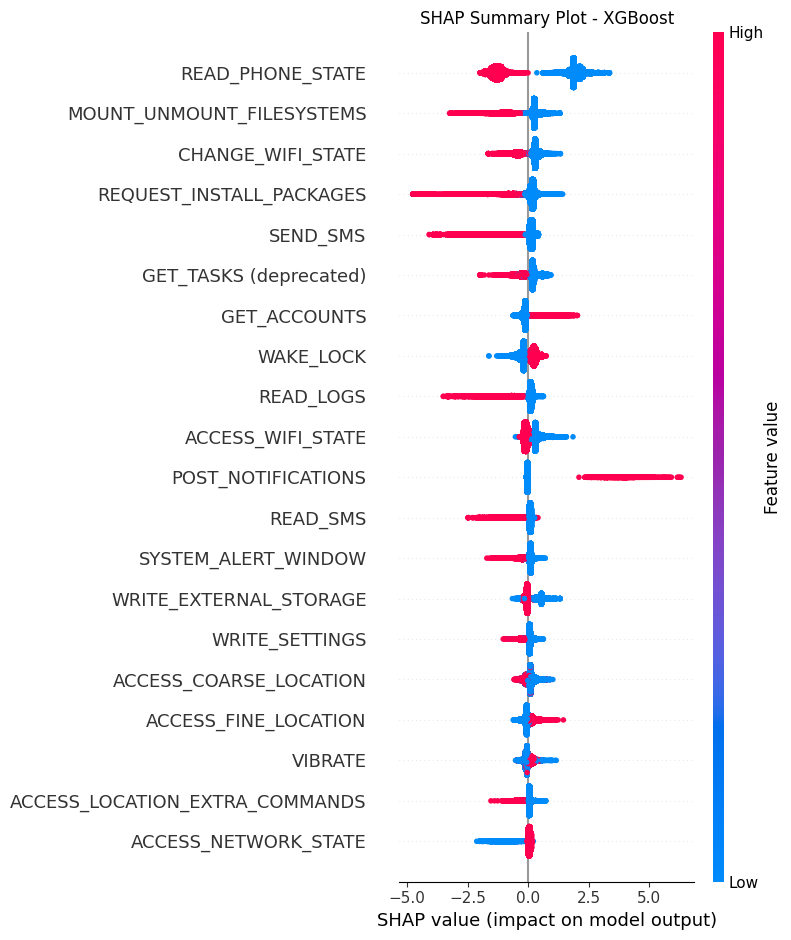

In [28]:
import shap
import matplotlib.pyplot as plt
import numpy as np
# ── 2. SHAP untuk XGBoost ────────────────────────────────────
print("\n--- SHAP Analysis: XGBoost ---")
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_train)

plt.figure()
shap.summary_plot(
    shap_values_xgb, X_train,
    class_names=class_labels,
    show=False
)
plt.title("SHAP Summary Plot - XGBoost")
plt.tight_layout()
plt.savefig("shap_xgb_summary.png", dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# ── SHAP dari X_train, bukan X_test ──────────────────────────
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_train)  # ✅ ganti ke X_train

if shap_values_xgb.ndim == 3:
    shap_xgb_mean = np.abs(shap_values_xgb).mean(axis=(0, 2))
else:
    shap_xgb_mean = np.abs(shap_values_xgb).mean(axis=0)

shap_xgb_df = pd.DataFrame({
    'Feature'        : X_train.columns,  # ✅ ganti ke X_train
    'SHAP_Importance': shap_xgb_mean
}).sort_values('SHAP_Importance', ascending=False).reset_index(drop=True)
print("\nTop 20 Features (XGBoost - SHAP):")
print(shap_xgb_df.head(20).to_string(index=False))



Top 20 Features (XGBoost - SHAP):
                       Feature  SHAP_Importance
              READ_PHONE_STATE         1.600112
     MOUNT_UNMOUNT_FILESYSTEMS         0.498613
             CHANGE_WIFI_STATE         0.344110
      REQUEST_INSTALL_PACKAGES         0.305221
                      SEND_SMS         0.298661
        GET_TASKS (deprecated)         0.293301
                  GET_ACCOUNTS         0.270226
                     WAKE_LOCK         0.269143
                     READ_LOGS         0.254429
             ACCESS_WIFI_STATE         0.182161
            POST_NOTIFICATIONS         0.164421
                      READ_SMS         0.161742
           SYSTEM_ALERT_WINDOW         0.155107
        WRITE_EXTERNAL_STORAGE         0.147484
                WRITE_SETTINGS         0.132048
        ACCESS_COARSE_LOCATION         0.123425
          ACCESS_FINE_LOCATION         0.119399
                       VIBRATE         0.110731
ACCESS_LOCATION_EXTRA_COMMANDS         0.105069
     

In [30]:
import numpy as np
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.combine import SMOTETomek, SMOTEENN
from sklearn.metrics import classification_report
import pandas as pd

# ── 1. Definisi persentil & SMOTE variants ───────────────────────────────────
percentiles = [10, 20, 30, 40, 50, 60, 70]
from sklearn.preprocessing import MinMaxScaler

smote_variants = {
    # 'SMOTE'           : SMOTE(random_state=42),
    # 'SMOTEENN'        : SMOTEENN(random_state=42),
    'SMOTETomek'      : SMOTETomek(random_state=42),
    # 'BorderlineSMOTE' : BorderlineSMOTE(random_state=42)
}

# ── 2. Loop persentil × SMOTE ────────────────────────────────────────────────
results_all = {}

for P in percentiles:
    # Hitung N fitur
    N_total    = len(shap_xgb_df)
    N_FEATURES = int(np.ceil(N_total * P / 100))

    # Ambil fitur
    selected_features = shap_xgb_df.head(N_FEATURES)['Feature'].tolist()

    X_train_p = X_train[selected_features]
    X_test_p  = X_test[selected_features]

    print(f"\n{'='*60}")
    print(f"  Persentil P={P}% → {N_FEATURES} fitur")
    print(f"{'='*60}")

    for smote_name, sampler in smote_variants.items():
        print(f"\n  [{smote_name}]")

        # Resample X_train
        X_res, y_res = sampler.fit_resample(X_train_p, y_train)
        print(f"  Shape train : {X_train_p.shape} → {X_res.shape}")
        
        # Normaliszation
        scaler = MinMaxScaler()
        X_train_scaled = scaler.fit_transform(X_res)
        X_test_scaled  = scaler.transform(X_test_p)

        # Retrain model
        xgb_ps = XGBClassifier(**xgb_model.get_params())
        xgb_ps.fit(X_train_scaled, y_res)

        # Evaluasi di test asli (tidak di-resample)
        y_pred = xgb_ps.predict(X_test_scaled)
        report = classification_report(y_test, y_pred, output_dict=True)

        print(classification_report(y_test, y_pred))

        # Simpan hasil
        key = f'P{P}_{smote_name}'
        results_all[key] = {
            'Persentil'   : P,
            'N Fitur'     : N_FEATURES,
            'SMOTE'       : smote_name,
            'Accuracy'    : report['accuracy'],
            'F1 Macro'    : report['macro avg']['f1-score'],
            'F1 Weighted' : report['weighted avg']['f1-score'],
            'Precision'   : report['macro avg']['precision'],
            'Recall'      : report['macro avg']['recall'],
        }

# ── 3. Tabel perbandingan ────────────────────────────────────────────────────
results_df = pd.DataFrame(results_all).T.round(4)
print("\n── Perbandingan Semua Kombinasi ──")
print(results_df.sort_values('F1 Macro', ascending=False).to_string())

# ── 4. Kombinasi terbaik ─────────────────────────────────────────────────────
best = results_df.sort_values('F1 Macro', ascending=False).iloc[0]
print(f"\n✅ Kombinasi terbaik:")
print(f"   Persentil : {best['Persentil']}%")
print(f"   N Fitur   : {best['N Fitur']}")
print(f"   SMOTE     : {best['SMOTE']}")
print(f"   F1 Macro  : {best['F1 Macro']}")


  Persentil P=10% → 19 fitur

  [SMOTETomek]
  Shape train : (101154, 19) → (115818, 19)
              precision    recall  f1-score   support

           0       0.94      0.94      0.94     10810
           1       0.96      0.96      0.96     14479

    accuracy                           0.95     25289
   macro avg       0.95      0.95      0.95     25289
weighted avg       0.95      0.95      0.95     25289


  Persentil P=20% → 38 fitur

  [SMOTETomek]
  Shape train : (101154, 38) → (115594, 38)
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     10810
           1       0.96      0.97      0.97     14479

    accuracy                           0.96     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.96      0.96      0.96     25289


  Persentil P=30% → 57 fitur

  [SMOTETomek]
  Shape train : (101154, 57) → (115534, 57)
              precision    recall  f1-score   support

           0       0.

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.combine import SMOTETomek
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import pandas as pd

# ── 1. Definisi persentil & model ───────────────────────────────────────────
percentiles = [10, 20, 30, 40, 50, 60, 70]

models = {
    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=7,
        learning_rate=0.2,
        random_state=42
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200,
        max_depth=None,
        learning_rate=0.2,
        class_weight='balanced',
        random_state=42,
        verbose = -1
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=5,
        class_weight='balanced',
        random_state=42
    )
}

sampler = SMOTETomek(random_state=42)


  Persentil P=10% → 19 fitur
  Shape train : (101154, 19) → (115818, 19)

  [XGBoost]
  Training Time : 0.7259s
  Testing Time  : 0.0141s
              precision    recall  f1-score   support

           1       0.94      0.94      0.94     10810
           0       0.96      0.96      0.96     14479

    accuracy                           0.95     25289
   macro avg       0.95      0.95      0.95     25289
weighted avg       0.95      0.95      0.95     25289



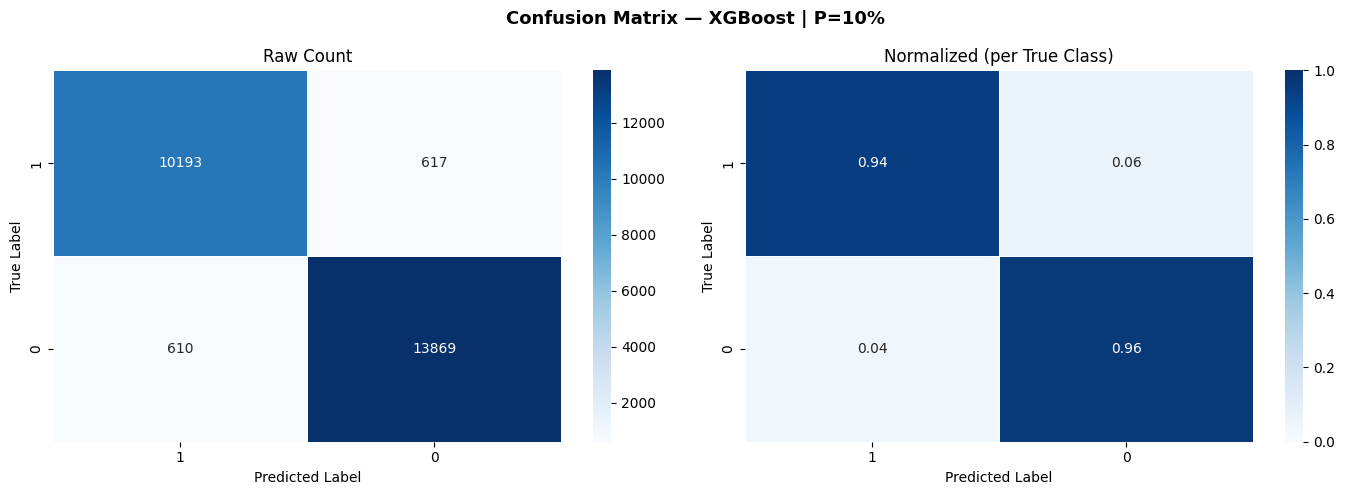


  [LightGBM]
  Training Time : 1.3768s
  Testing Time  : 0.0325s
              precision    recall  f1-score   support

           1       0.94      0.94      0.94     10810
           0       0.96      0.96      0.96     14479

    accuracy                           0.95     25289
   macro avg       0.95      0.95      0.95     25289
weighted avg       0.95      0.95      0.95     25289



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


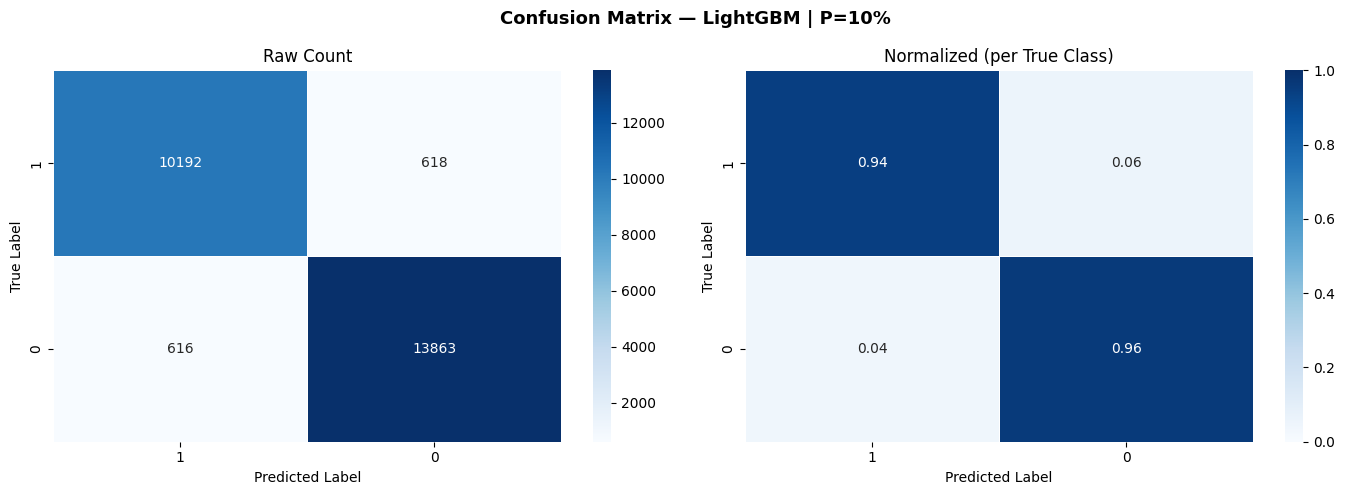


  [RandomForest]
  Training Time : 5.9250s
  Testing Time  : 0.4251s
              precision    recall  f1-score   support

           1       0.94      0.94      0.94     10810
           0       0.96      0.96      0.96     14479

    accuracy                           0.95     25289
   macro avg       0.95      0.95      0.95     25289
weighted avg       0.95      0.95      0.95     25289



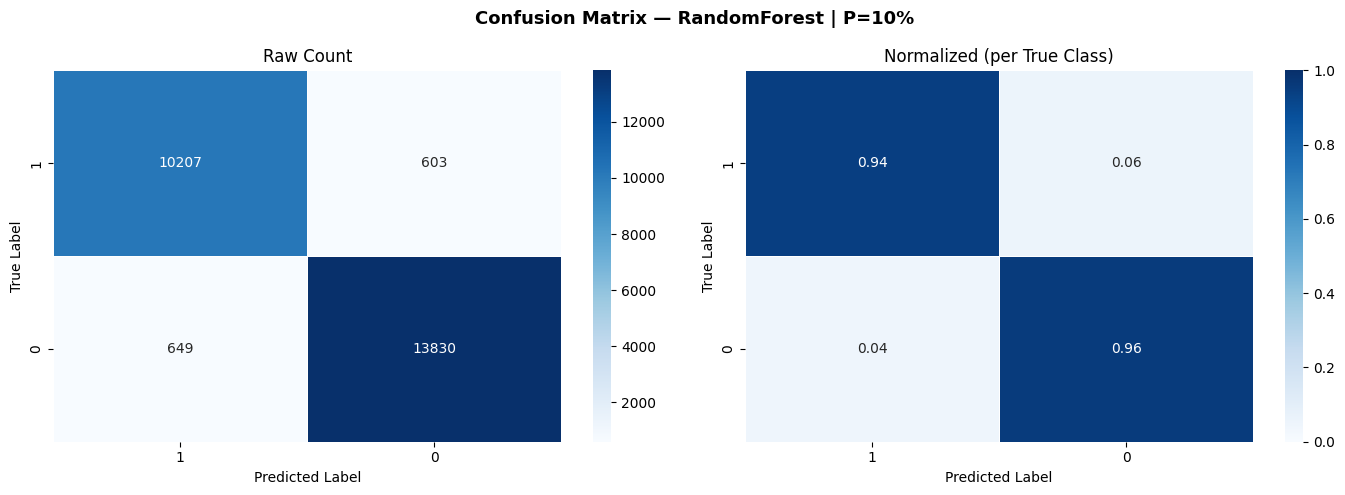


  Persentil P=20% → 38 fitur
  Shape train : (101154, 38) → (115594, 38)

  [XGBoost]
  Training Time : 0.7988s
  Testing Time  : 0.0124s
              precision    recall  f1-score   support

           1       0.96      0.95      0.95     10810
           0       0.96      0.97      0.97     14479

    accuracy                           0.96     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.96      0.96      0.96     25289



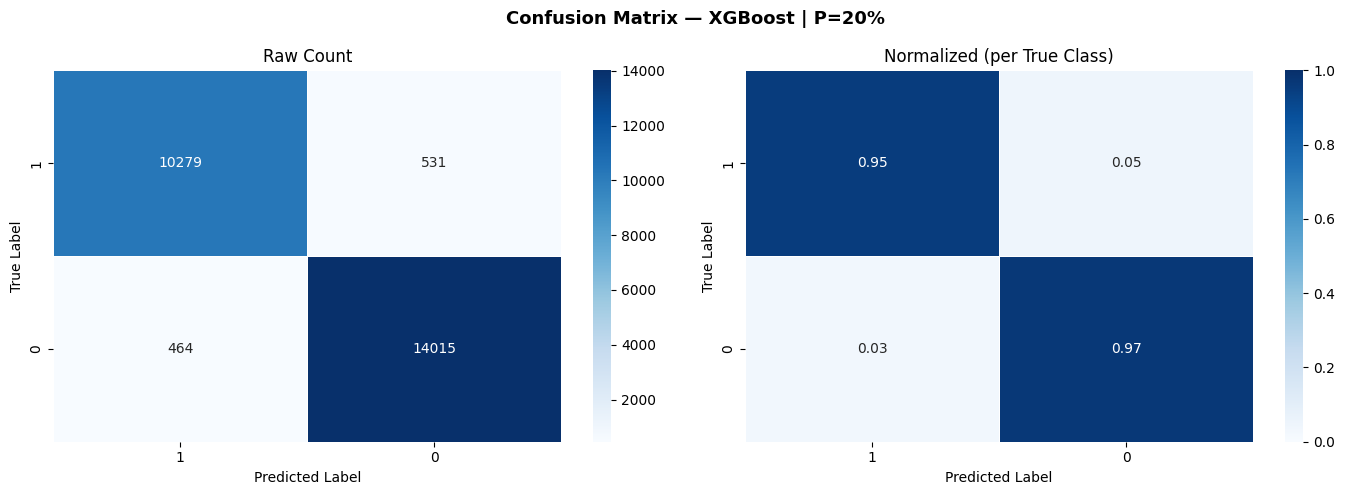


  [LightGBM]
  Training Time : 1.4381s
  Testing Time  : 0.0402s
              precision    recall  f1-score   support

           1       0.95      0.95      0.95     10810
           0       0.96      0.96      0.96     14479

    accuracy                           0.96     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.96      0.96      0.96     25289



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


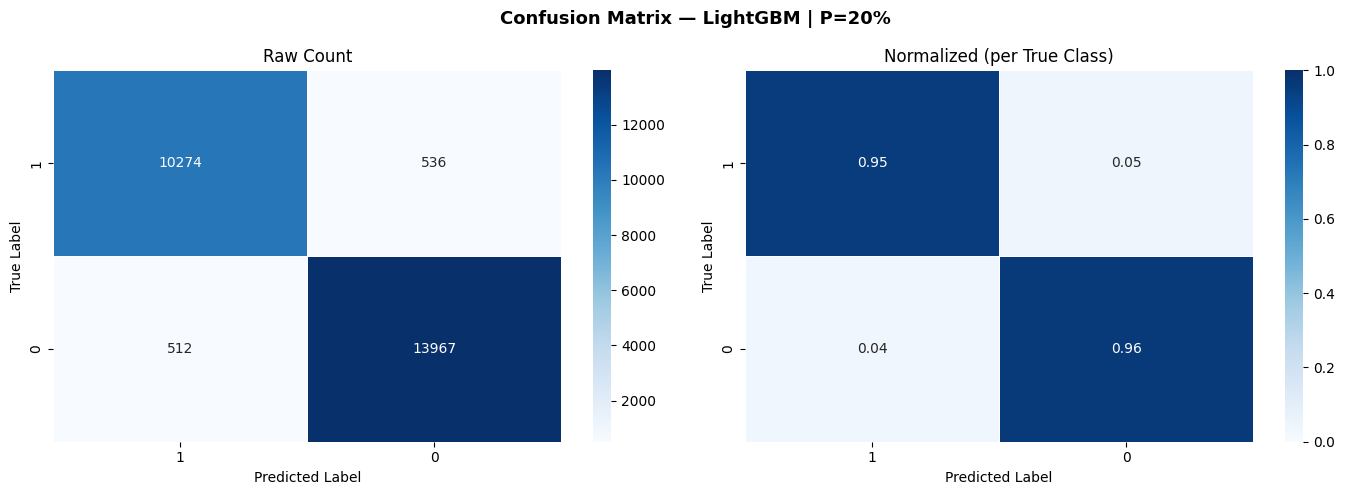


  [RandomForest]
  Training Time : 9.0557s
  Testing Time  : 0.5531s
              precision    recall  f1-score   support

           1       0.95      0.95      0.95     10810
           0       0.97      0.97      0.97     14479

    accuracy                           0.96     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.96      0.96      0.96     25289



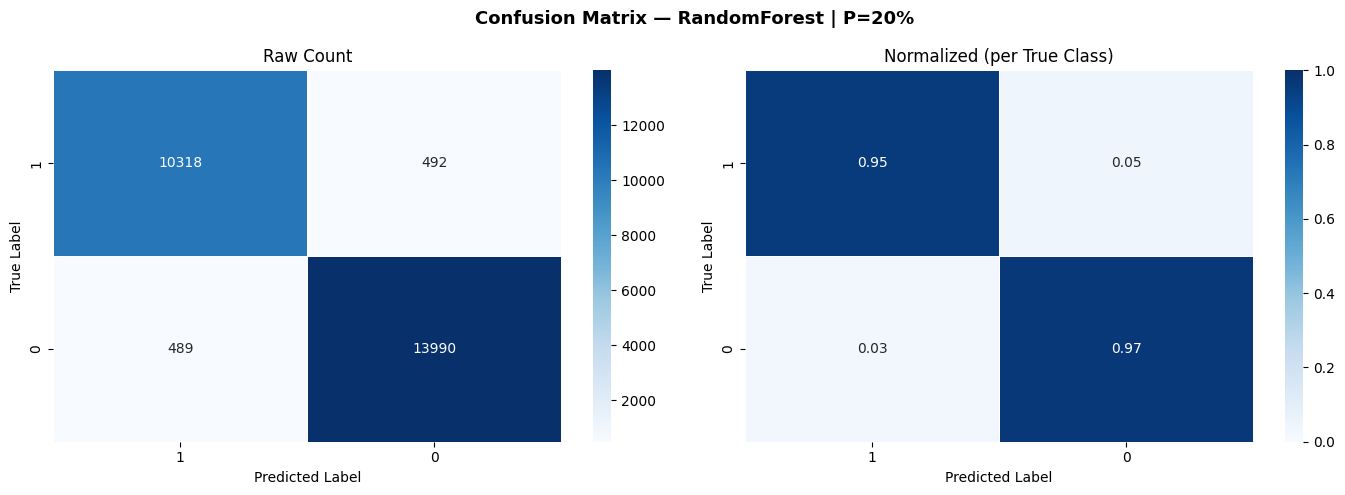


  Persentil P=30% → 57 fitur
  Shape train : (101154, 57) → (115534, 57)

  [XGBoost]
  Training Time : 0.8940s
  Testing Time  : 0.0124s
              precision    recall  f1-score   support

           1       0.96      0.95      0.96     10810
           0       0.96      0.97      0.97     14479

    accuracy                           0.96     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.96      0.96      0.96     25289



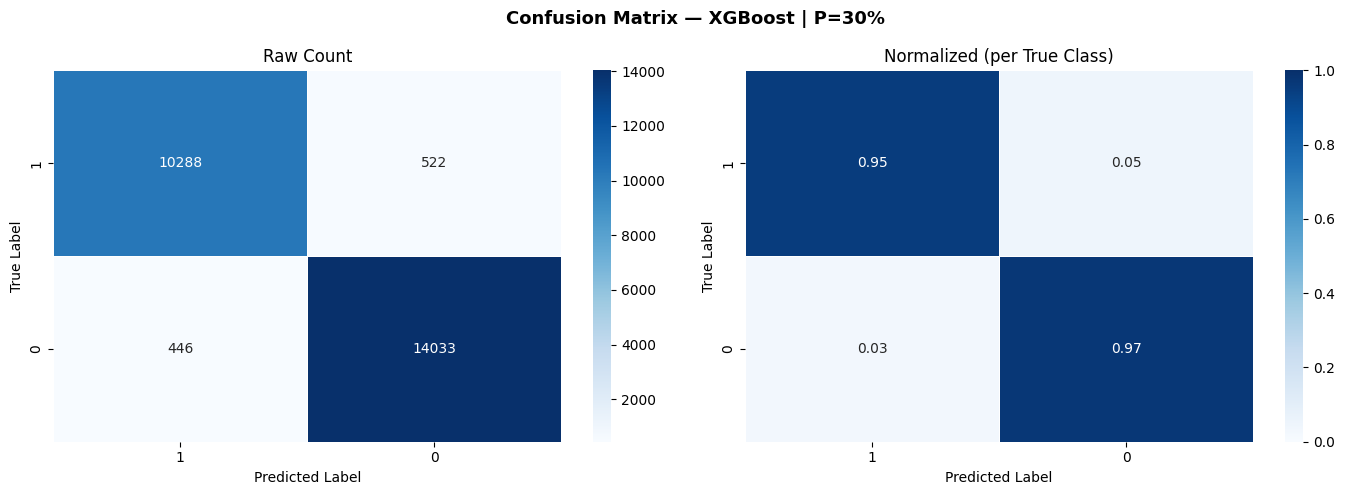


  [LightGBM]
  Training Time : 1.4871s
  Testing Time  : 0.0437s
              precision    recall  f1-score   support

           1       0.96      0.95      0.95     10810
           0       0.96      0.97      0.97     14479

    accuracy                           0.96     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.96      0.96      0.96     25289



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


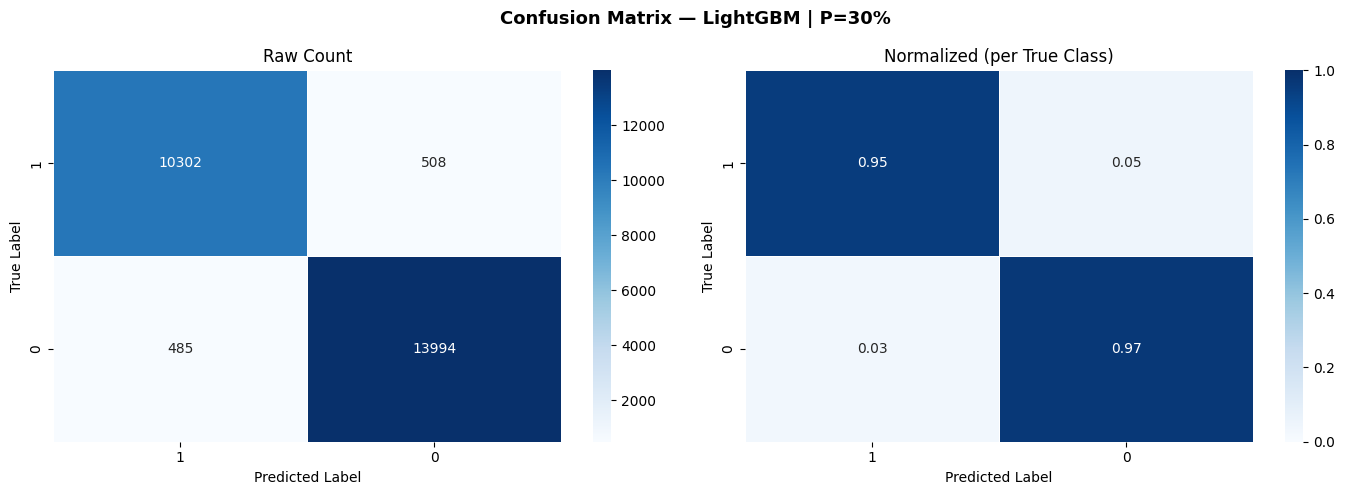


  [RandomForest]
  Training Time : 10.5568s
  Testing Time  : 0.5746s
              precision    recall  f1-score   support

           1       0.96      0.96      0.96     10810
           0       0.97      0.97      0.97     14479

    accuracy                           0.96     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.96      0.96      0.96     25289



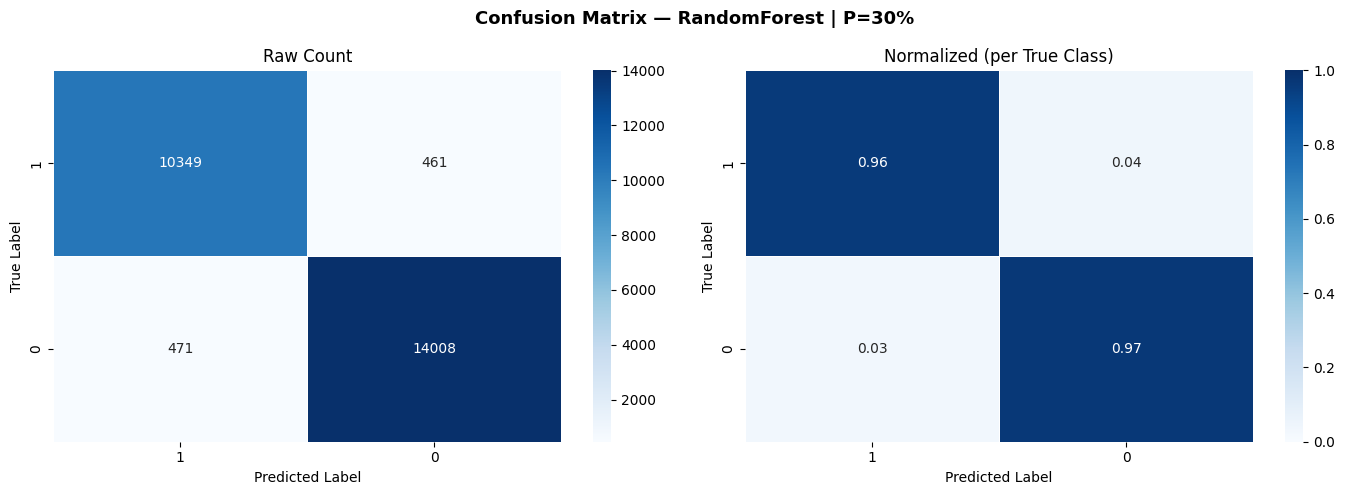


  Persentil P=40% → 76 fitur
  Shape train : (101154, 76) → (115540, 76)

  [XGBoost]
  Training Time : 0.9870s
  Testing Time  : 0.0128s
              precision    recall  f1-score   support

           1       0.96      0.95      0.96     10810
           0       0.97      0.97      0.97     14479

    accuracy                           0.96     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.96      0.96      0.96     25289



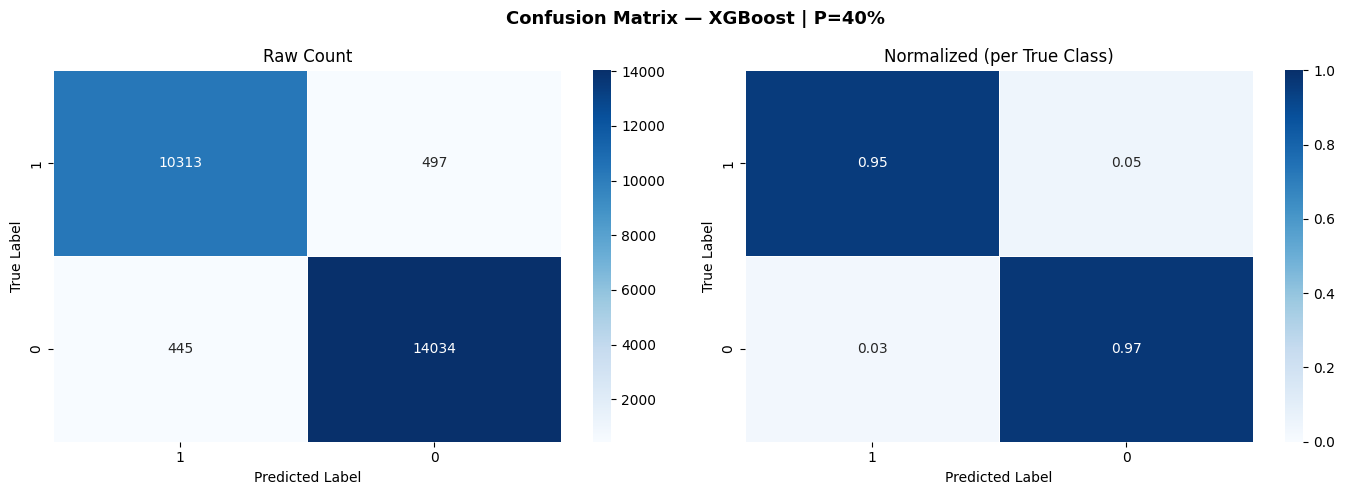


  [LightGBM]
  Training Time : 1.5761s
  Testing Time  : 0.0433s
              precision    recall  f1-score   support

           1       0.96      0.95      0.96     10810
           0       0.97      0.97      0.97     14479

    accuracy                           0.96     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.96      0.96      0.96     25289



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


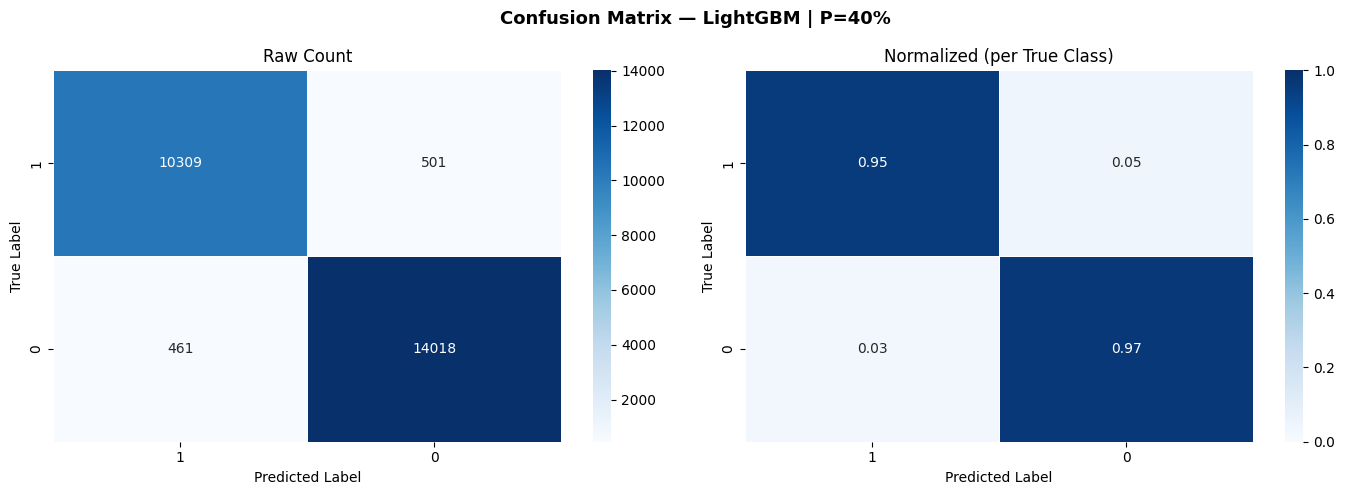


  [RandomForest]
  Training Time : 12.2323s
  Testing Time  : 0.6078s
              precision    recall  f1-score   support

           1       0.96      0.96      0.96     10810
           0       0.97      0.97      0.97     14479

    accuracy                           0.97     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.97      0.97      0.97     25289



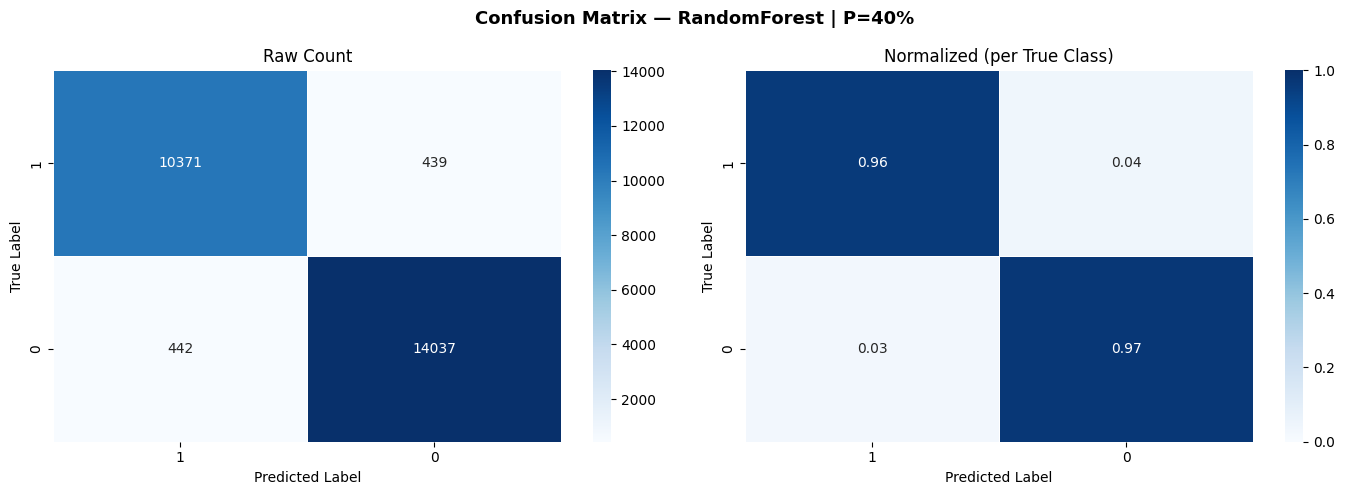


  Persentil P=50% → 95 fitur
  Shape train : (101154, 95) → (115556, 95)

  [XGBoost]
  Training Time : 1.0729s
  Testing Time  : 0.0138s
              precision    recall  f1-score   support

           1       0.96      0.95      0.96     10810
           0       0.97      0.97      0.97     14479

    accuracy                           0.96     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.96      0.96      0.96     25289



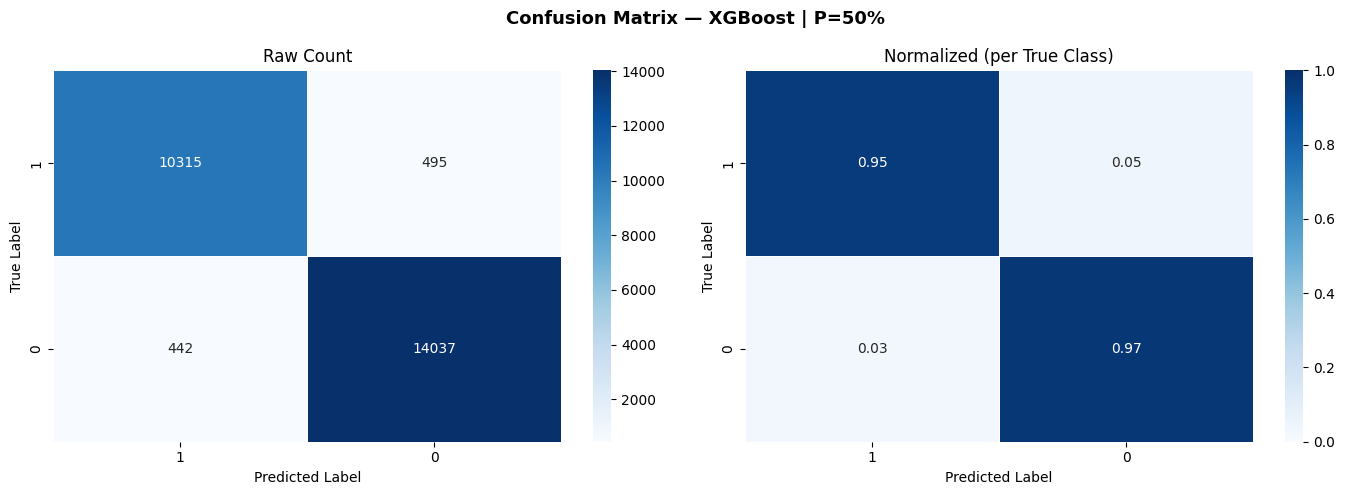


  [LightGBM]
  Training Time : 1.5586s
  Testing Time  : 0.0444s
              precision    recall  f1-score   support

           1       0.96      0.95      0.96     10810
           0       0.97      0.97      0.97     14479

    accuracy                           0.96     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.96      0.96      0.96     25289



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


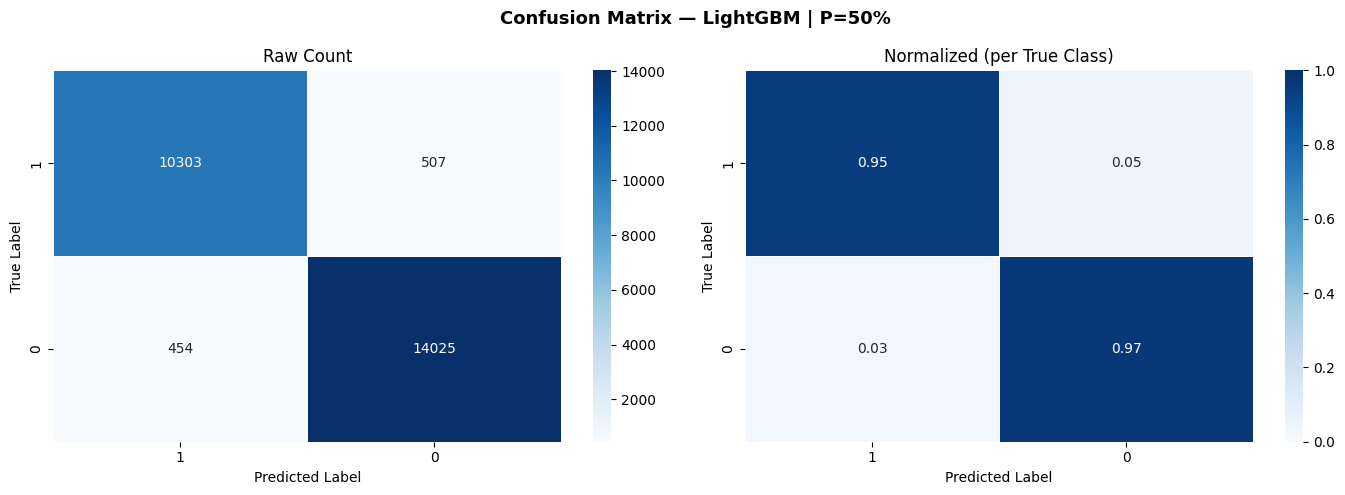


  [RandomForest]
  Training Time : 13.9995s
  Testing Time  : 0.6221s
              precision    recall  f1-score   support

           1       0.96      0.96      0.96     10810
           0       0.97      0.97      0.97     14479

    accuracy                           0.96     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.96      0.96      0.96     25289



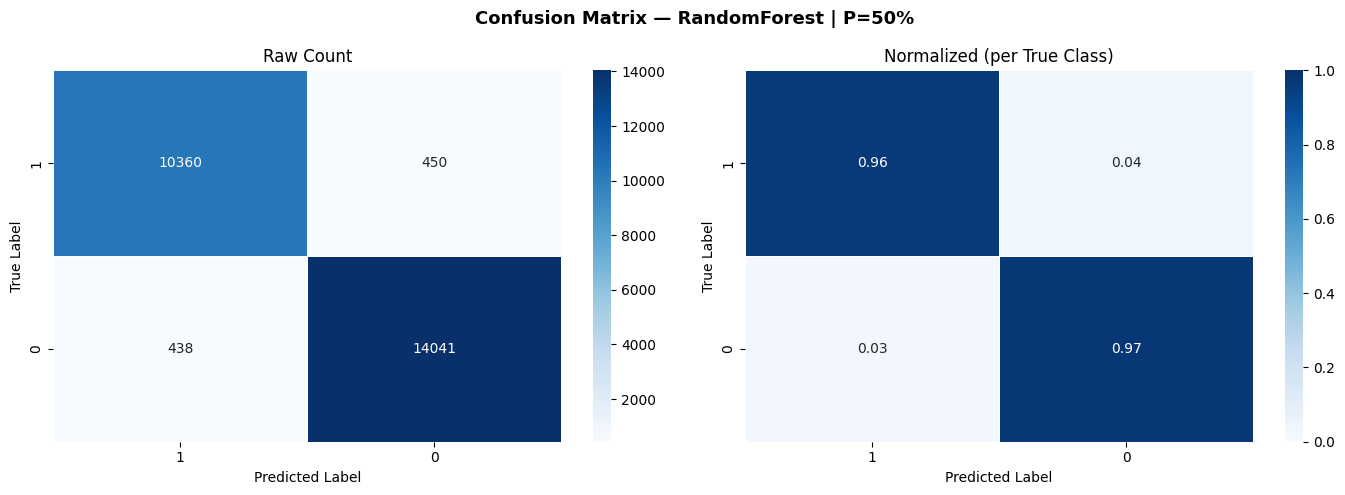


  Persentil P=60% → 114 fitur
  Shape train : (101154, 114) → (115538, 114)

  [XGBoost]
  Training Time : 1.2466s
  Testing Time  : 0.0140s
              precision    recall  f1-score   support

           1       0.96      0.95      0.96     10810
           0       0.97      0.97      0.97     14479

    accuracy                           0.96     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.96      0.96      0.96     25289



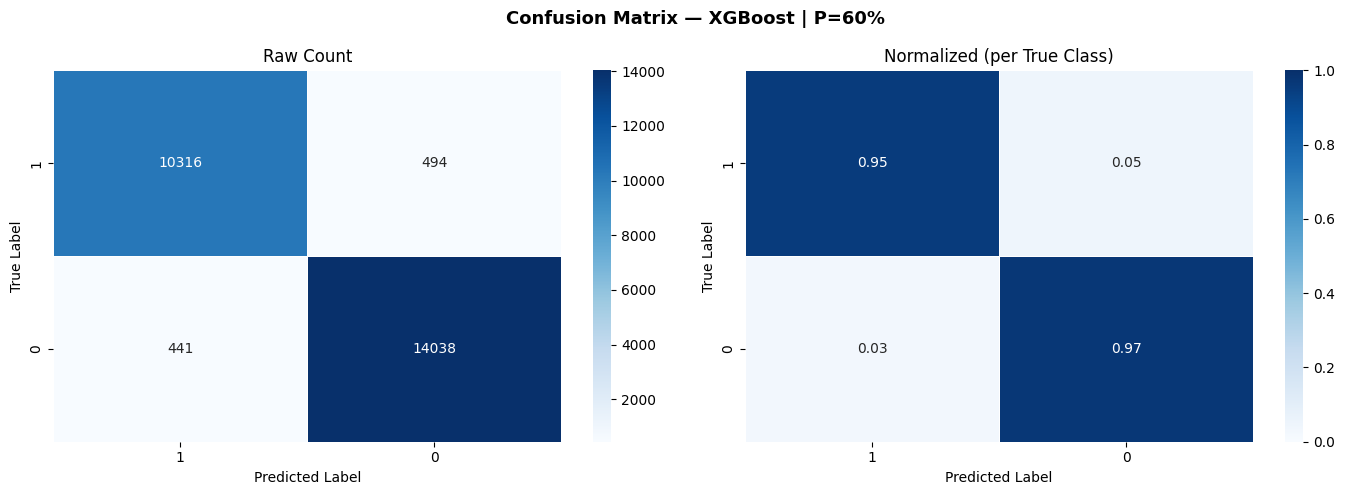


  [LightGBM]
  Training Time : 1.5614s
  Testing Time  : 0.0496s
              precision    recall  f1-score   support

           1       0.95      0.95      0.95     10810
           0       0.97      0.97      0.97     14479

    accuracy                           0.96     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.96      0.96      0.96     25289



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


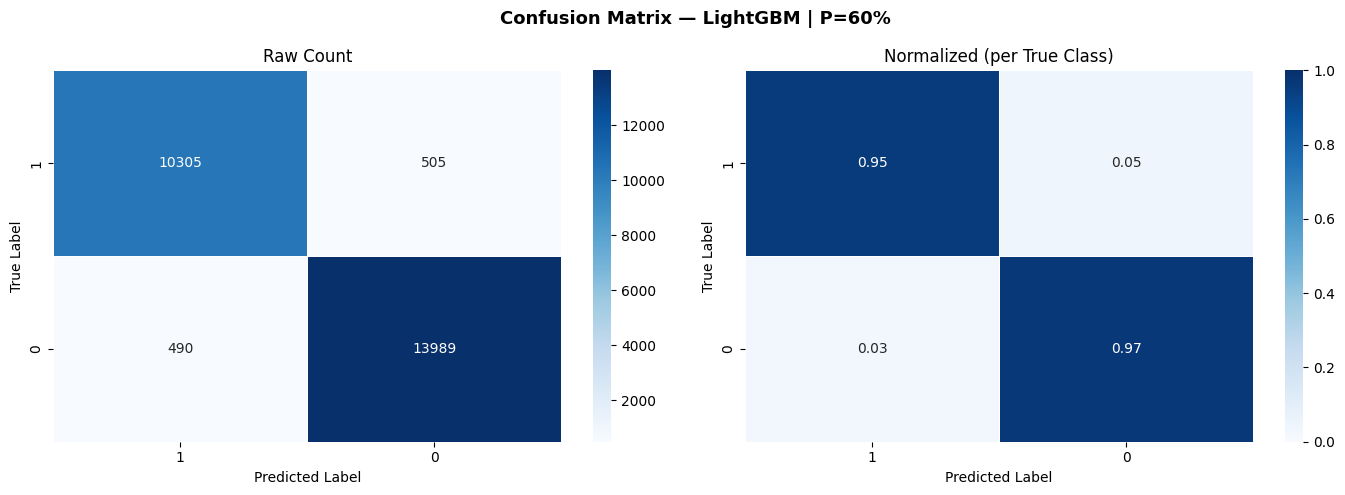


  [RandomForest]
  Training Time : 16.5027s
  Testing Time  : 0.6736s
              precision    recall  f1-score   support

           1       0.96      0.96      0.96     10810
           0       0.97      0.97      0.97     14479

    accuracy                           0.96     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.96      0.96      0.96     25289



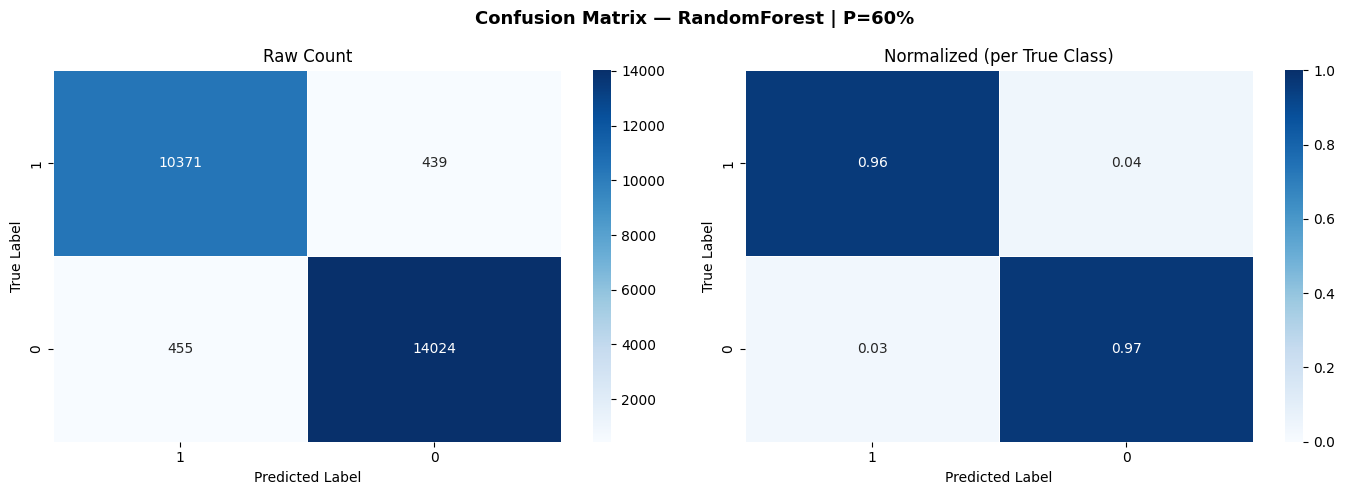


  Persentil P=70% → 133 fitur
  Shape train : (101154, 133) → (115560, 133)

  [XGBoost]
  Training Time : 1.3194s
  Testing Time  : 0.0134s
              precision    recall  f1-score   support

           1       0.96      0.95      0.96     10810
           0       0.96      0.97      0.97     14479

    accuracy                           0.96     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.96      0.96      0.96     25289



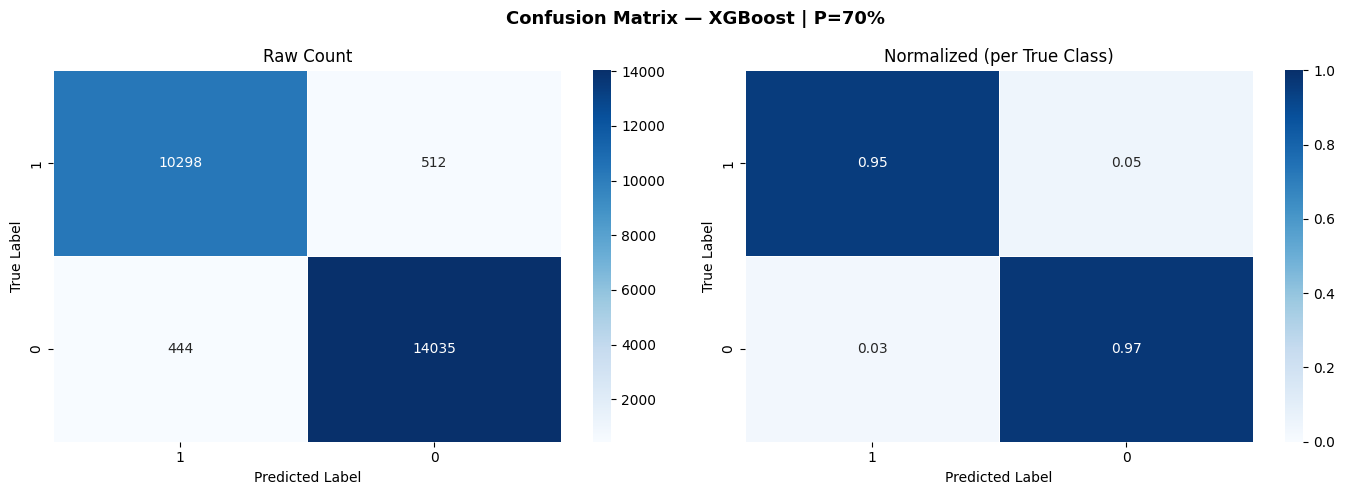


  [LightGBM]
  Training Time : 1.5894s
  Testing Time  : 0.0546s
              precision    recall  f1-score   support

           1       0.96      0.95      0.96     10810
           0       0.96      0.97      0.97     14479

    accuracy                           0.96     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.96      0.96      0.96     25289



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


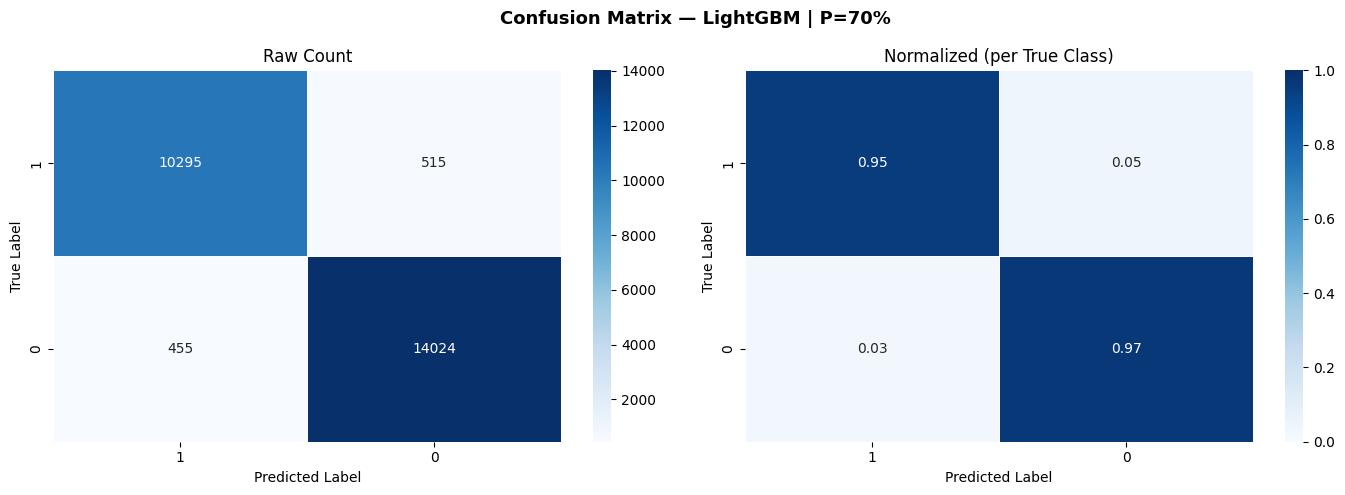


  [RandomForest]
  Training Time : 18.3826s
  Testing Time  : 0.7011s
              precision    recall  f1-score   support

           1       0.96      0.96      0.96     10810
           0       0.97      0.97      0.97     14479

    accuracy                           0.97     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.97      0.97      0.97     25289



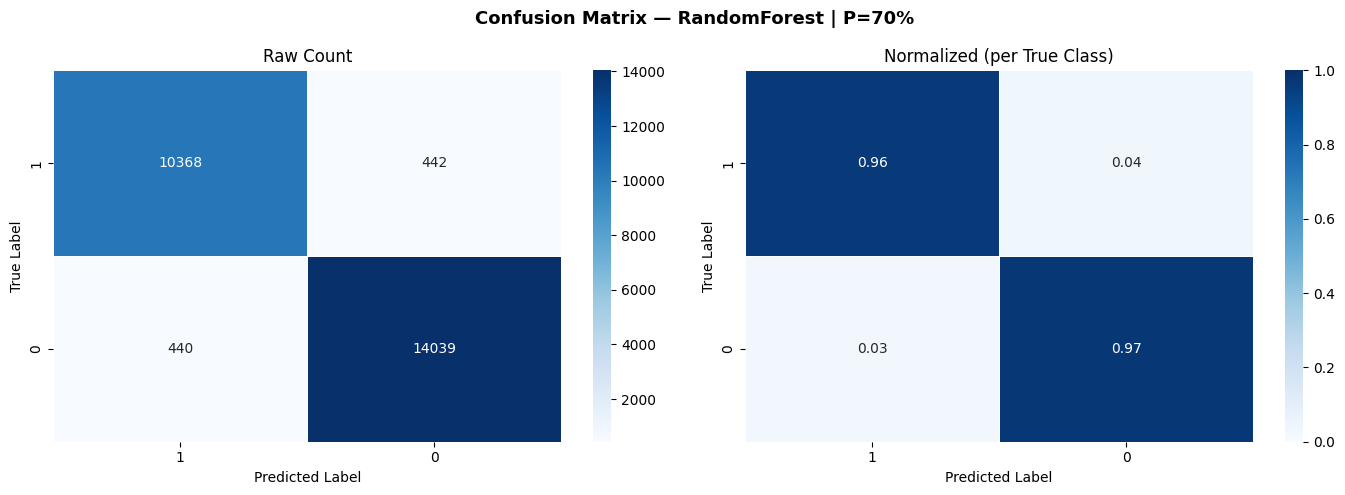


── Perbandingan Semua Kombinasi (SMOTETomek) ──
                 Persentil N Fitur         Model  Accuracy  F1 Macro F1 Weighted Precision Macro Precision Weighted Recall Macro Recall Weighted Training Time Testing Time
P40_RandomForest        40      76  RandomForest  0.965163  0.964415    0.965163        0.964399           0.965164     0.964431        0.965163       12.2323       0.6078
P70_RandomForest        70     133  RandomForest  0.965123  0.964372    0.965123        0.964383           0.965122     0.964362        0.965123       18.3826       0.7011
P50_RandomForest        50      95  RandomForest  0.964886  0.964126    0.964883        0.964192           0.964881     0.964061        0.964886       13.9995       0.6221
P60_RandomForest        60     114  RandomForest  0.964649  0.963895    0.964652        0.963809           0.964656     0.963982        0.964649       16.5027       0.6736
P30_RandomForest        30      57  RandomForest  0.963146  0.962358    0.963148        0.9

In [32]:
# ── 2. Helper plot confusion matrix ─────────────────────────────────────────
def plot_confusion_matrix(y_true, y_pred, model_name, percentile, class_labels):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Confusion Matrix — {model_name} | P={percentile}%', fontsize=13, fontweight='bold')

    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_labels, yticklabels=class_labels,
        ax=axes[0], linewidths=0.5
    )
    axes[0].set_title('Raw Count')
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('True Label')

    sns.heatmap(
        cm_norm, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=class_labels, yticklabels=class_labels,
        ax=axes[1], linewidths=0.5, vmin=0, vmax=1
    )
    axes[1].set_title('Normalized (per True Class)')
    axes[1].set_xlabel('Predicted Label')
    axes[1].set_ylabel('True Label')

    plt.tight_layout()
    plt.show()

# ── 3. Loop persentil × model ────────────────────────────────────────────────
results_all = {}

for P in percentiles:
    N_total    = len(shap_xgb_df)
    N_FEATURES = int(np.ceil(N_total * P / 100))

    selected_features = shap_xgb_df.head(N_FEATURES)['Feature'].tolist()

    X_train_p = X_train[selected_features]
    X_test_p  = X_test[selected_features]

    X_res, y_res = sampler.fit_resample(X_train_p, y_train)

    print(f"\n{'='*60}")
    print(f"  Persentil P={P}% → {N_FEATURES} fitur")
    print(f"  Shape train : {X_train_p.shape} → {X_res.shape}")
    print(f"{'='*60}")

    for model_name, clf in models.items():
        print(f"\n  [{model_name}]")

        clf_fit = clf.__class__(**clf.get_params())

        # Normalization
        scaler = MinMaxScaler()
        X_train_scaled = scaler.fit_transform(X_res)
        X_test_scaled  = scaler.transform(X_test_p)

        start = time.time()
        clf_fit.fit(X_train_scaled, y_res)
        train_time = time.time() - start
        print(f"  Training Time : {train_time:.4f}s")

        # ── Testing Time ────────────────────────────────────────────────────
        start = time.time()
        y_pred = clf_fit.predict(X_test_scaled)
        test_time = time.time() - start
        print(f"  Testing Time  : {test_time:.4f}s")

        report = classification_report(y_test, y_pred, output_dict=True)
        print(classification_report(y_test, y_pred, target_names=[str(x) for x in class_labels]))

        # ── Confusion Matrix ────────────────────────────────────────────────
        plot_confusion_matrix(y_test, y_pred, model_name, P, class_labels)

        key = f'P{P}_{model_name}'
        results_all[key] = {
            'Persentil'          : P,
            'N Fitur'            : N_FEATURES,
            'Model'              : model_name,
            'Accuracy'           : report['accuracy'],
            'F1 Macro'           : report['macro avg']['f1-score'],
            'F1 Weighted'        : report['weighted avg']['f1-score'],
            'Precision Macro'    : report['macro avg']['precision'],
            'Precision Weighted' : report['weighted avg']['precision'],
            'Recall Macro'       : report['macro avg']['recall'],
            'Recall Weighted'    : report['weighted avg']['recall'],
            'Training Time'      : round(train_time, 4),
            'Testing Time'       : round(test_time, 4),
        }

# ── 4. Tabel perbandingan ────────────────────────────────────────────────────
results_df = pd.DataFrame(results_all).T.round(4)
print("\n── Perbandingan Semua Kombinasi (SMOTETomek) ──")
print(results_df.sort_values('F1 Macro', ascending=False).to_string())

# ── 5. Kombinasi terbaik ─────────────────────────────────────────────────────
best = results_df.sort_values('F1 Macro', ascending=False).iloc[0]
print(f"\n✅ Kombinasi terbaik:")
print(f"   Persentil : {best['Persentil']}%")
print(f"   N Fitur   : {best['N Fitur']}")
print(f"   Model     : {best['Model']}")
print(f"   F1 Macro  : {best['F1 Macro']}")